# Experimental: detector-level pyramid WFS

> **Experimental module.** The pyramid-WFS forward model in
> `shwfs_ao.experimental.pwfs` is deliberately isolated from the validated
> Shack–Hartmann pipeline. It is provided for exploration, not as a supported
> backend, and makes no equivalence claim.

**Scientific question.** Does the experimental detector-level pyramid wavefront
sensor produce the expected pyramid-WFS behaviour — a signal that grows roughly
linearly with a small input tilt and then saturates — and does its photon noise
fall as the inverse square root of the flux?

The forward model and its detector measurement are installed
`shwfs_ao.experimental.pwfs` APIs; the notebook only drives them.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.experimental.pwfs import (
    add_tilt_phase,
    make_pwfs_grid,
    pwfs_detector_measurement_from_phase,
    pwfs_reference_signal,
    pwfs_signal_from_phase,
)

SEED = 20240517
N_FFT = 256
N_PUPIL = 64
SEPARATION = 64
TILT_AMPLITUDES = (0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8)
PHOTON_BUDGETS = (1e4, 1e5, 1e6, 1e7)
N_NOISE_DRAWS = 6

## Configuration

In [2]:
x, y, _, _, pupil = make_pwfs_grid(n_fft=N_FFT, n_pupil=N_PUPIL)
reference = np.asarray(
    pwfs_reference_signal(pupil, x, y, n_pupil=N_PUPIL, separation=SEPARATION)
)
print(f"pupil samples: {int(pupil.sum())}; signal length: {reference.size}")

pupil samples: 3209; signal length: 6414


## Simulation call

In [3]:
def tilt_response(amplitude):
    phase = add_tilt_phase(x, y, amplitude, 0.0)
    signal = np.asarray(
        pwfs_signal_from_phase(
            np.where(pupil, phase, 0.0), pupil, x, y,
            n_pupil=N_PUPIL, separation=SEPARATION,
        )
    )
    delta = signal - reference
    return float(np.sqrt(np.mean(delta**2)))

response = {amplitude: tilt_response(amplitude) for amplitude in TILT_AMPLITUDES}

def noise_level(photons):
    base = np.where(pupil, add_tilt_phase(x, y, 0.1, 0.0), 0.0)
    draws = [
        np.asarray(
            pwfs_detector_measurement_from_phase(
                base, pupil, x, y, n_photons=photons, read_noise_e=0.0,
                seed=SEED + draw, n_pupil=N_PUPIL, separation=SEPARATION,
            )
        )
        for draw in range(N_NOISE_DRAWS)
    ]
    return float(np.std(np.stack(draws), axis=0).mean())

noise = {photons: noise_level(photons) for photons in PHOTON_BUDGETS}

## Diagnostic table

In [4]:
response_table = pd.DataFrame(
    [(amplitude, response[amplitude]) for amplitude in TILT_AMPLITUDES],
    columns=["tilt amplitude (lambda/D-like)", "RMS |signal - reference|"],
)
response_table

,tilt amplitude (lambda/D-like),RMS |signal - reference|
0,0.00,0.000000
1,0.02,0.092659
2,0.05,0.225076
3,0.10,0.409629
4,0.20,0.613636
5,0.40,0.666996
6,0.80,0.685565


## Plot

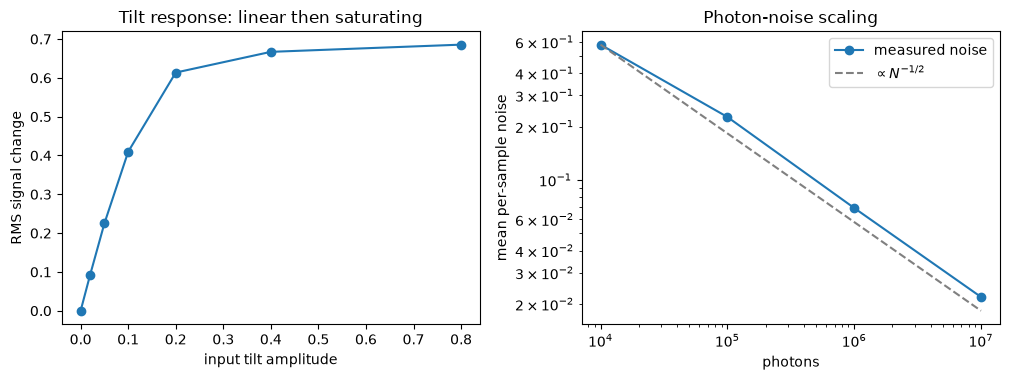

In [5]:
amplitudes = np.array(TILT_AMPLITUDES)
signal = np.array([response[a] for a in TILT_AMPLITUDES])
photons = np.array(PHOTON_BUDGETS)
noise_values = np.array([noise[p] for p in PHOTON_BUDGETS])
sqrt_reference = noise_values[0] * np.sqrt(photons[0] / photons)

figure, (left, right) = plt.subplots(1, 2, figsize=(10.2, 3.9))
left.plot(amplitudes, signal, "o-")
left.set_xlabel("input tilt amplitude")
left.set_ylabel("RMS signal change")
left.set_title("Tilt response: linear then saturating")
right.loglog(photons, noise_values, "o-", label="measured noise")
right.loglog(photons, sqrt_reference, "--", color="0.5", label=r"$\propto N^{-1/2}$")
right.set_xlabel("photons")
right.set_ylabel("mean per-sample noise")
right.set_title("Photon-noise scaling")
right.legend()
figure.tight_layout()
plt.show()

## Interpretation

The signal grows almost linearly for small tilts and then flattens as the input
exceeds the sensor's linear range — the hallmark pyramid-WFS response, which is
why real pyramid sensors modulate to extend the linear regime. The detector
noise falls along the inverse-square-root reference, confirming the measurement
is shot-noise limited over this flux range. Both behaviours match qualitative
pyramid-WFS expectations.

## Limitations

- **Experimental and unvalidated.** This forward model is isolated from the
  Shack–Hartmann pipeline and is not cross-checked against HCIPy; no equivalence
  claim is made.
- No modulation is applied, so the linear range is narrow.
- Signals are summarized by an RMS magnitude rather than resolved per axis; a
  full study would calibrate a modal interaction matrix.